# Training Analysis: Q-Learning vs Q-Learning Fuzzy

Comparative analysis of Q-Table size, cumulative reward, and per-step reward between Q-Learning and Q-Learning Fuzzy models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

# Load data
df_ql = pd.read_csv('data-training/19-02-2026/train_qlearning_1771479713_.csv')
df_qf = pd.read_csv('data-training/19-02-2026/train_qlearningfuzzy_1771479783_.csv')

# Create comparison dfs with only overlapping episodes
common_episodes = sorted(set(df_ql['episode'].unique()) & set(df_qf['episode'].unique()))
df_ql_cmp = df_ql[df_ql['episode'].isin(common_episodes)].copy()
df_qf_cmp = df_qf[df_qf['episode'].isin(common_episodes)].copy()

print(f'Q-Learning      : {len(df_ql)} steps, {df_ql["episode"].nunique()} episodes')
print(f'Q-Learning Fuzzy: {len(df_qf)} steps, {df_qf["episode"].nunique()} episodes')
print(f'Common episodes : {len(common_episodes)} (used for comparison)')
print(f'Columns: {list(df_ql.columns)}')

Q-Learning      : 1800 steps, 60 episodes
Q-Learning Fuzzy: 1800 steps, 60 episodes
Common episodes : 60 (used for comparison)
Columns: ['timestamp', 'episode', 'step', 'action', 'reward', 'cumulative_reward', 'epsilon', 'q_table_size', 'iteration', 'replica_state', 'cpu_usage', 'memory_usage', 'response_time', 'response_time_percentage', 'optimal', 'balanced', 'wasteful', 'critical', 'cost_penalty', 'replica_ratio']


## 1. Q-Table Size Growth

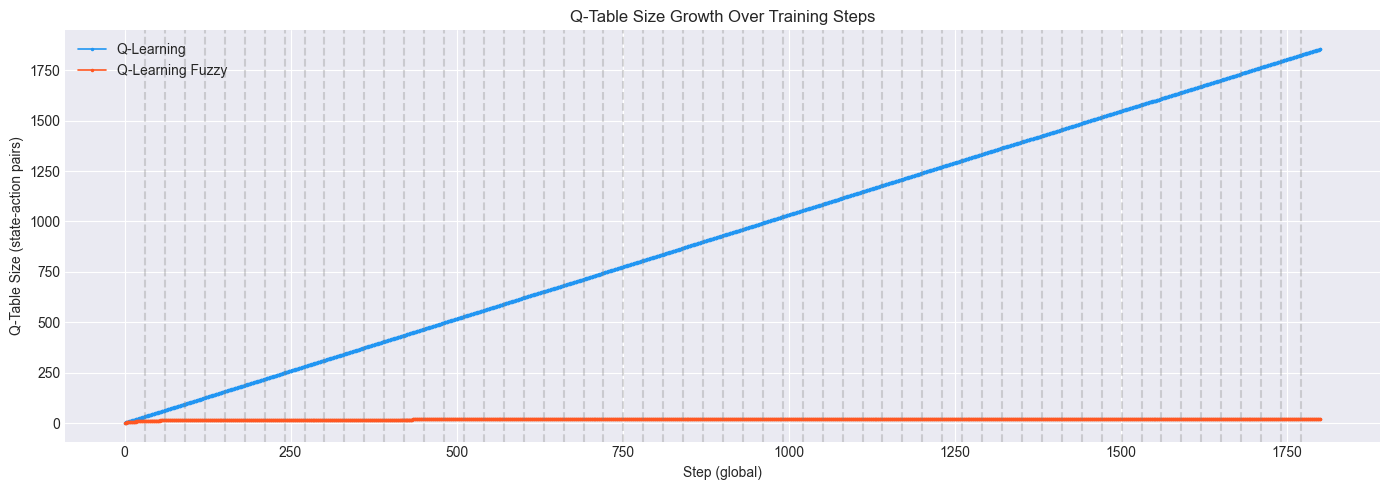


Q-Learning      - Final Q-Table size: 1855
Q-Learning Fuzzy - Final Q-Table size: 21
Ratio: Q-Learning is 88.3x larger than Q-Fuzzy


In [2]:
# --- Q-Table size over all steps ---
fig, ax = plt.subplots(figsize=(14, 5))
steps_ql = range(1, len(df_ql) + 1)
steps_qf = range(1, len(df_qf) + 1)

ax.plot(steps_ql, df_ql['q_table_size'], marker='.', markersize=3, linewidth=1.2, label='Q-Learning', color='#2196F3')
ax.plot(steps_qf, df_qf['q_table_size'], marker='.', markersize=3, linewidth=1.2, label='Q-Learning Fuzzy', color='#FF5722')
ax.set_xlabel('Step (global)')
ax.set_ylabel('Q-Table Size (state-action pairs)')
ax.set_title('Q-Table Size Growth Over Training Steps')
ax.legend()

# Add episode boundaries
for ep in df_ql['episode'].unique()[1:]:
    idx = df_ql[df_ql['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\nQ-Learning      - Final Q-Table size: {df_ql["q_table_size"].iloc[-1]}')
print(f'Q-Learning Fuzzy - Final Q-Table size: {df_qf["q_table_size"].iloc[-1]}')
print(f'Ratio: Q-Learning is {df_ql["q_table_size"].iloc[-1] / df_qf["q_table_size"].iloc[-1]:.1f}x larger than Q-Fuzzy')

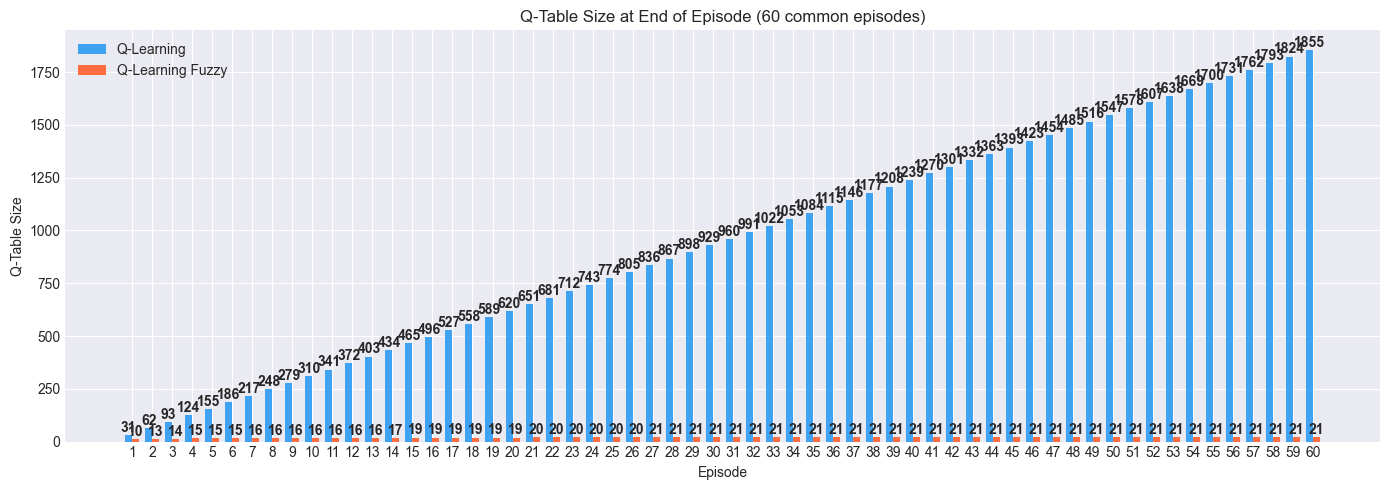

In [3]:
# --- Q-Table size at end of each episode (common episodes only) ---
fig, ax = plt.subplots(figsize=(14, 5))

ql_ep_end = df_ql_cmp.groupby('episode')['q_table_size'].last()
qf_ep_end = df_qf_cmp.groupby('episode')['q_table_size'].last()

x = np.arange(len(common_episodes))
width = 0.35
bars1 = ax.bar(x - width/2, ql_ep_end.values, width, label='Q-Learning', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, qf_ep_end.values, width, label='Q-Learning Fuzzy', color='#FF5722', alpha=0.85)

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Episode')
ax.set_ylabel('Q-Table Size')
ax.set_title(f'Q-Table Size at End of Episode ({len(common_episodes)} common episodes)')
ax.set_xticks(x)
ax.set_xticklabels(common_episodes)
ax.legend()

plt.tight_layout()
plt.show()

## 2. Cumulative Reward per Episode

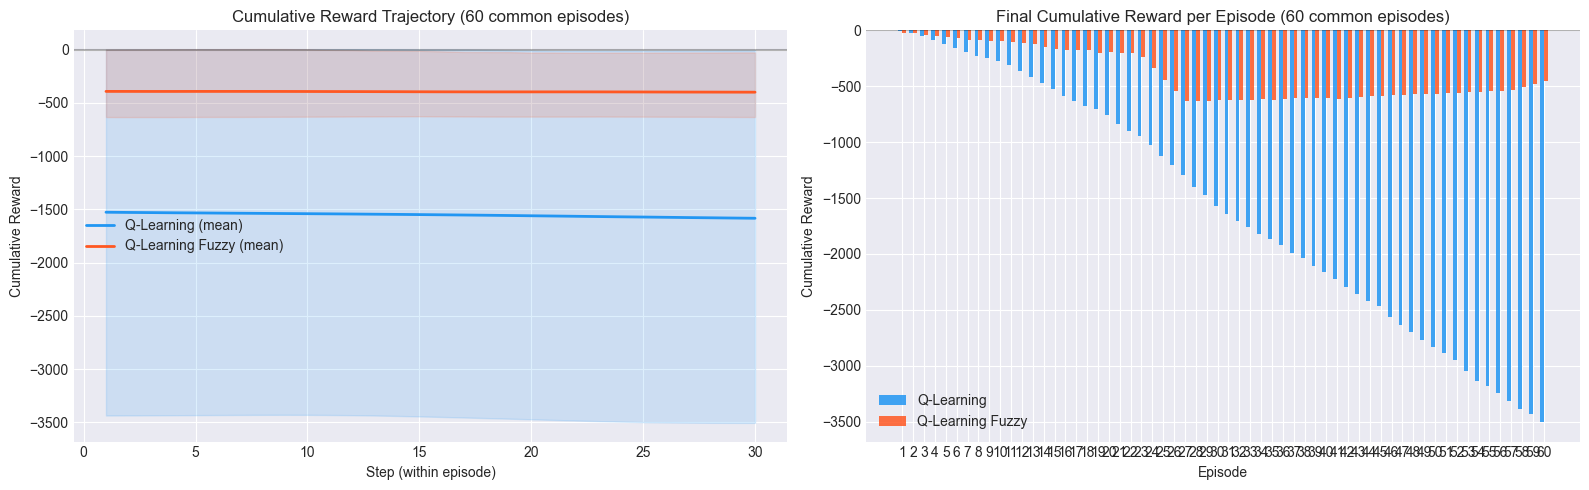


Final Cumulative Reward (common episodes):
  Episode 1: Q-Learning = -7.7402, Q-Fuzzy = -27.2687
  Episode 2: Q-Learning = -23.9507, Q-Fuzzy = -26.7933
  Episode 3: Q-Learning = -48.6100, Q-Fuzzy = -37.2360
  Episode 4: Q-Learning = -84.0131, Q-Fuzzy = -52.4419
  Episode 5: Q-Learning = -124.5322, Q-Fuzzy = -61.3549
  Episode 6: Q-Learning = -156.7625, Q-Fuzzy = -64.0359
  Episode 7: Q-Learning = -189.8336, Q-Fuzzy = -83.4314
  Episode 8: Q-Learning = -225.6777, Q-Fuzzy = -89.2584
  Episode 9: Q-Learning = -249.6012, Q-Fuzzy = -95.3180
  Episode 10: Q-Learning = -270.2865, Q-Fuzzy = -94.0615
  Episode 11: Q-Learning = -310.5307, Q-Fuzzy = -104.1477
  Episode 12: Q-Learning = -364.0161, Q-Fuzzy = -115.9706
  Episode 13: Q-Learning = -418.1423, Q-Fuzzy = -123.8411
  Episode 14: Q-Learning = -472.2977, Q-Fuzzy = -151.2922
  Episode 15: Q-Learning = -527.6259, Q-Fuzzy = -169.5745
  Episode 16: Q-Learning = -586.1703, Q-Fuzzy = -172.7243
  Episode 17: Q-Learning = -630.7226, Q-Fuzzy = -179

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Mean cumulative reward trajectory with min/max bands ---
ax = axes[0]

max_steps = max(df_ql_cmp.groupby('episode')['step'].max().max(), 
                df_qf_cmp.groupby('episode')['step'].max().max())

for label, df_cmp, color in [('Q-Learning', df_ql_cmp, '#2196F3'), ('Q-Learning Fuzzy', df_qf_cmp, '#FF5722')]:
    stats = df_cmp.groupby('step')['cumulative_reward'].agg(['mean', 'min', 'max'])
    ax.plot(stats.index, stats['mean'], linewidth=2, label=f'{label} (mean)', color=color)
    ax.fill_between(stats.index, stats['min'], stats['max'], alpha=0.15, color=color)

ax.set_xlabel('Step (within episode)')
ax.set_ylabel('Cumulative Reward')
ax.set_title(f'Cumulative Reward Trajectory ({len(common_episodes)} common episodes)')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# --- Right: Final cumulative reward per episode (bar chart, common episodes) ---
ax = axes[1]
ql_final = df_ql_cmp.groupby('episode')['cumulative_reward'].last()
qf_final = df_qf_cmp.groupby('episode')['cumulative_reward'].last()

x = np.arange(len(common_episodes))
width = 0.35
bars1 = ax.bar(x - width/2, ql_final.values, width, label='Q-Learning', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, qf_final.values, width, label='Q-Learning Fuzzy', color='#FF5722', alpha=0.85)

ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title(f'Final Cumulative Reward per Episode ({len(common_episodes)} common episodes)')
ax.set_xticks(x)
ax.set_xticklabels(common_episodes)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nFinal Cumulative Reward (common episodes):')
for ep in common_episodes:
    print(f'  Episode {ep}: Q-Learning = {ql_final[ep]:.4f}, Q-Fuzzy = {qf_final[ep]:.4f}')

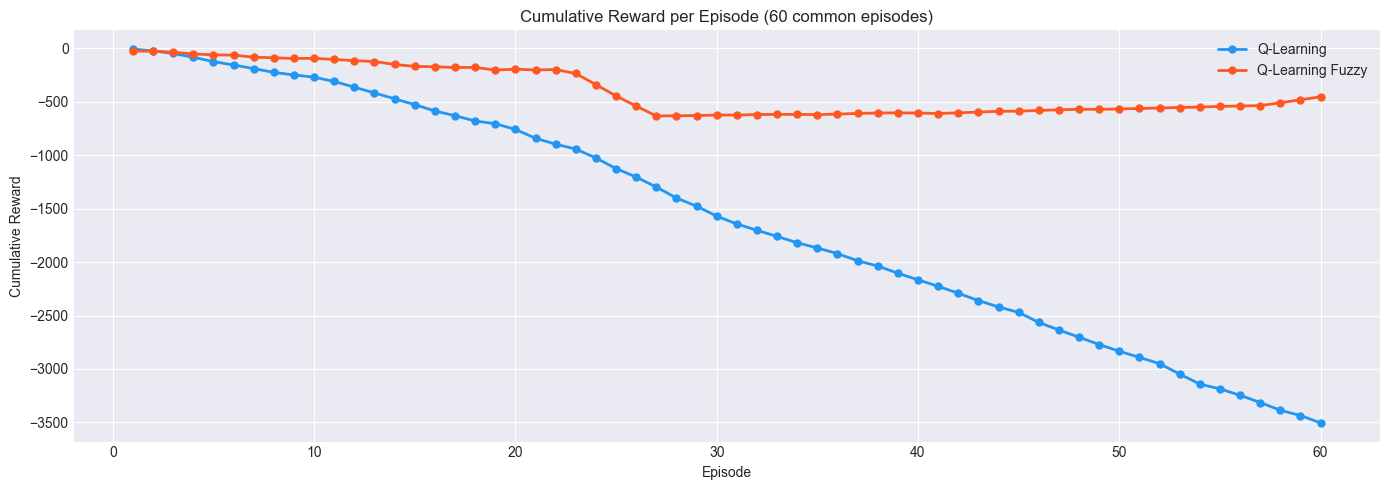

In [5]:
# Cumulative Reward per Episode - Comparison (line chart, common episodes)
ql_cum_per_ep = df_ql_cmp.groupby('episode')['cumulative_reward'].last()
qf_cum_per_ep = df_qf_cmp.groupby('episode')['cumulative_reward'].last()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ql_cum_per_ep.index, ql_cum_per_ep.values, marker='o', markersize=5,
        linewidth=2, label='Q-Learning', color='#2196F3')
ax.plot(qf_cum_per_ep.index, qf_cum_per_ep.values, marker='o', markersize=5,
        linewidth=2, label='Q-Learning Fuzzy', color='#FF5722')

ax.set_xlabel('Episode')
ax.set_ylabel('Cumulative Reward')
ax.set_title(f'Cumulative Reward per Episode ({len(common_episodes)} common episodes)')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

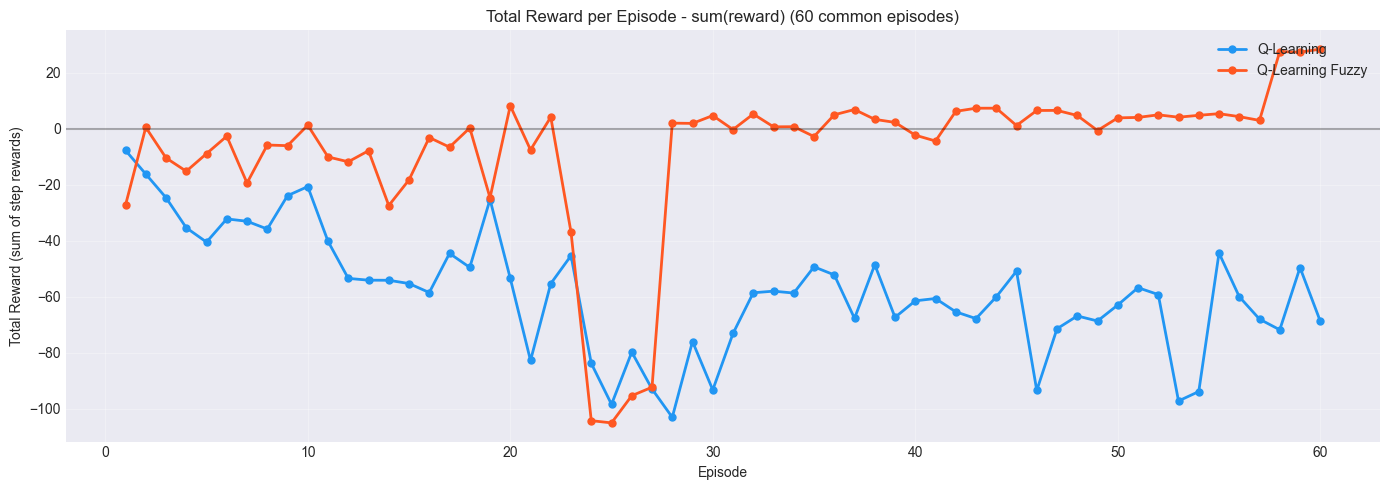

In [6]:
# Cumulative Reward per Episode - Computed from sum(reward) per episode
# Unlike cumulative_reward field which accumulates across episodes, this resets each episode
ql_reward_sum = df_ql_cmp.groupby('episode')['reward'].sum()
qf_reward_sum = df_qf_cmp.groupby('episode')['reward'].sum()

# --- Line chart ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(ql_reward_sum.index, ql_reward_sum.values, marker='o', markersize=5,
        linewidth=2, label='Q-Learning', color='#2196F3')
ax.plot(qf_reward_sum.index, qf_reward_sum.values, marker='o', markersize=5,
        linewidth=2, label='Q-Learning Fuzzy', color='#FF5722')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward (sum of step rewards)')
ax.set_title(f'Total Reward per Episode - sum(reward) ({len(common_episodes)} common episodes)')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

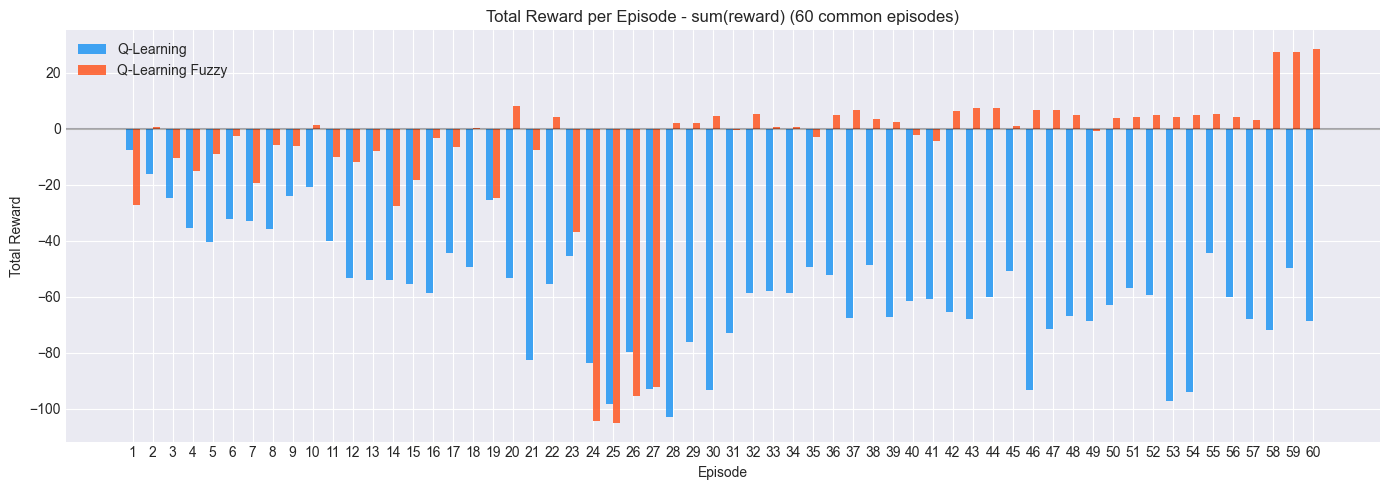


Total Reward per Episode (sum of step rewards):
 Episode     Q-Learning        Q-Fuzzy     Difference
-------------------------------------------------------
       1        -7.7402       -27.2687        19.5285
       2       -16.2105         0.4755       -16.6860
       3       -24.6593       -10.4427       -14.2165
       4       -35.4031       -15.2059       -20.1973
       5       -40.5191        -8.9131       -31.6060
       6       -32.2304        -2.6809       -29.5495
       7       -33.0711       -19.3955       -13.6756
       8       -35.8441        -5.8270       -30.0170
       9       -23.9234        -6.0595       -17.8639
      10       -20.6853         1.2565       -21.9418
      11       -40.2443       -10.0862       -30.1581
      12       -53.4854       -11.8229       -41.6624
      13       -54.1262        -7.8705       -46.2557
      14       -54.1554       -27.4511       -26.7042
      15       -55.3283       -18.2822       -37.0460
      16       -58.5443        

In [7]:
# --- Bar chart ---
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(common_episodes))
width = 0.35
ax.bar(x - width/2, ql_reward_sum.values, width, label='Q-Learning', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, qf_reward_sum.values, width, label='Q-Learning Fuzzy', color='#FF5722', alpha=0.85)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward')
ax.set_title(f'Total Reward per Episode - sum(reward) ({len(common_episodes)} common episodes)')
ax.set_xticks(x)
ax.set_xticklabels(common_episodes)
ax.legend()

plt.tight_layout()
plt.show()

# Stats
print('\nTotal Reward per Episode (sum of step rewards):')
print(f'{"Episode":>8} {"Q-Learning":>14} {"Q-Fuzzy":>14} {"Difference":>14}')
print('-' * 55)
for ep in common_episodes:
    ql_val = ql_reward_sum[ep]
    qf_val = qf_reward_sum[ep]
    print(f'{ep:>8} {ql_val:>14.4f} {qf_val:>14.4f} {ql_val - qf_val:>14.4f}')
print(f'\n{"Mean":>8} {ql_reward_sum.mean():>14.4f} {qf_reward_sum.mean():>14.4f} {(ql_reward_sum - qf_reward_sum).mean():>14.4f}')

## 3. Per-Step Reward Analysis

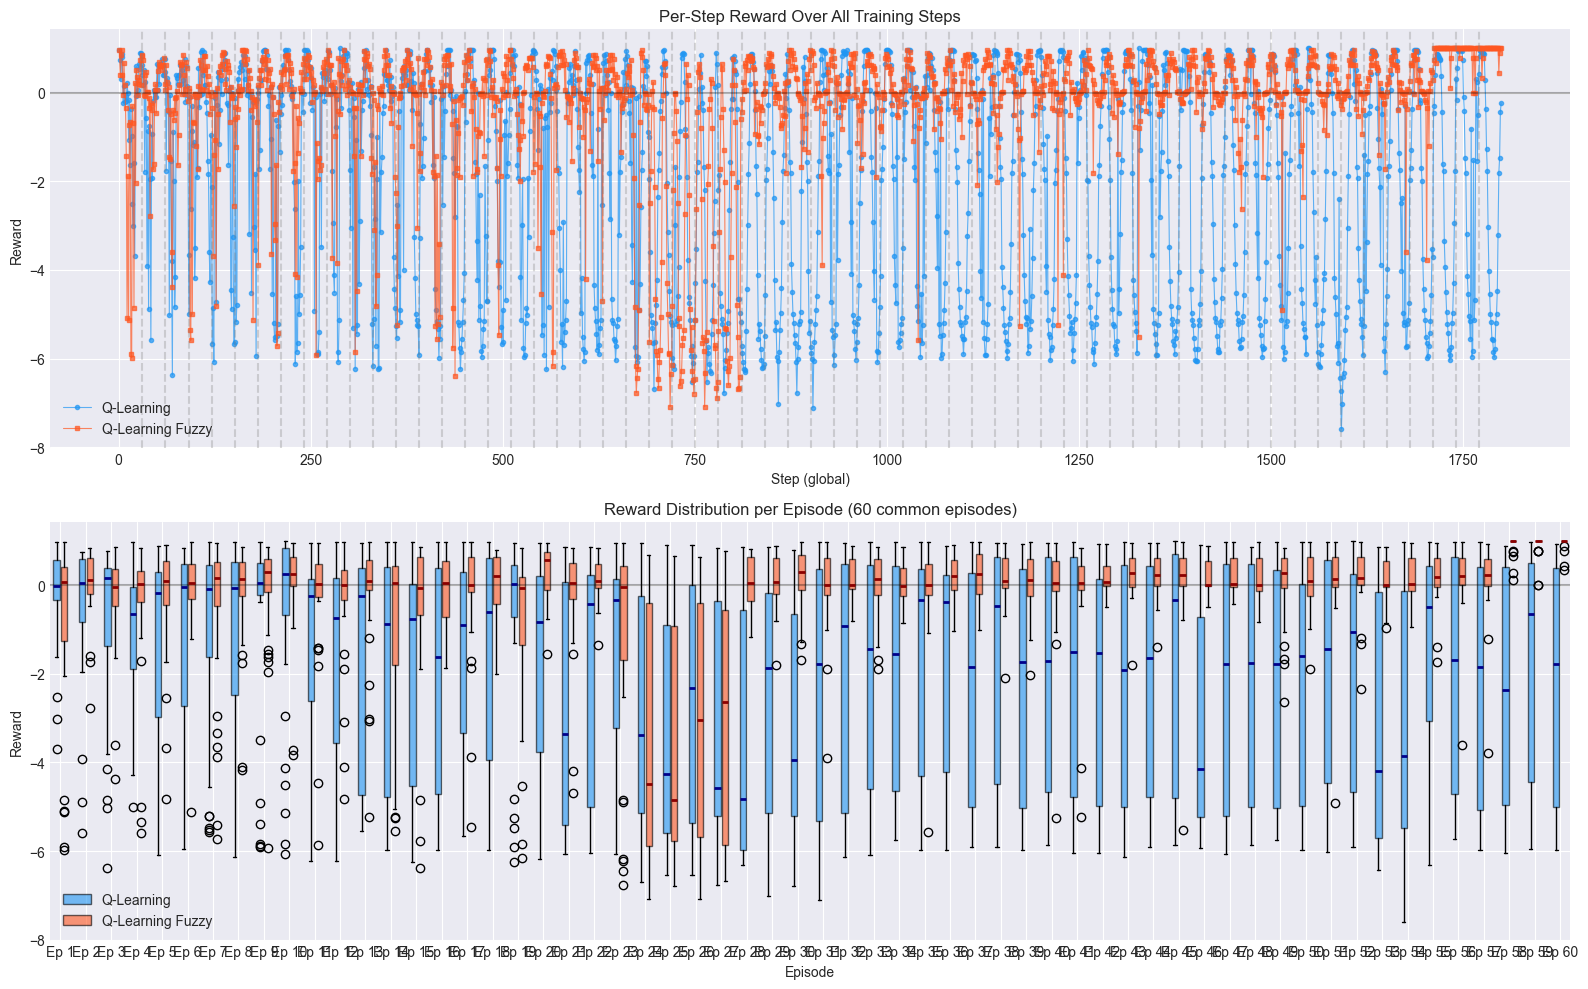

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Top: Per-step reward over all steps ---
ax = axes[0]
steps_ql = range(1, len(df_ql) + 1)
steps_qf = range(1, len(df_qf) + 1)

ax.plot(steps_ql, df_ql['reward'], marker='o', markersize=3, linewidth=0.8, label='Q-Learning', color='#2196F3', alpha=0.7)
ax.plot(steps_qf, df_qf['reward'], marker='s', markersize=3, linewidth=0.8, label='Q-Learning Fuzzy', color='#FF5722', alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Step (global)')
ax.set_ylabel('Reward')
ax.set_title('Per-Step Reward Over All Training Steps')
ax.legend()

# Add episode boundaries
for ep in df_ql['episode'].unique()[1:]:
    idx = df_ql[df_ql['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.3, label='Episode boundary' if ep == df_ql['episode'].unique()[1] else '')

# --- Bottom: Reward distribution per episode (box plot, common episodes) ---
ax = axes[1]

ql_rewards_by_ep = [df_ql_cmp[df_ql_cmp['episode'] == ep]['reward'].values for ep in common_episodes]
qf_rewards_by_ep = [df_qf_cmp[df_qf_cmp['episode'] == ep]['reward'].values for ep in common_episodes]

positions_ql = np.arange(len(common_episodes)) * 2 - 0.3
positions_qf = np.arange(len(common_episodes)) * 2 + 0.3

bp1 = ax.boxplot(ql_rewards_by_ep, positions=positions_ql, widths=0.5,
                  patch_artist=True, boxprops=dict(facecolor='#2196F3', alpha=0.6),
                  medianprops=dict(color='darkblue', linewidth=2))
bp2 = ax.boxplot(qf_rewards_by_ep, positions=positions_qf, widths=0.5,
                  patch_artist=True, boxprops=dict(facecolor='#FF5722', alpha=0.6),
                  medianprops=dict(color='darkred', linewidth=2))

ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title(f'Reward Distribution per Episode ({len(common_episodes)} common episodes)')
ax.set_xticks(np.arange(len(common_episodes)) * 2)
ax.set_xticklabels([f'Ep {ep}' for ep in common_episodes])
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Q-Learning', 'Q-Learning Fuzzy'])
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Reward Statistics Summary

In [9]:
print('=' * 70)
print('REWARD STATISTICS SUMMARY')
print('=' * 70)

for name, df in [('Q-Learning', df_ql), ('Q-Learning Fuzzy', df_qf)]:
    print(f'\n--- {name} ---')
    print(f'  Total steps     : {len(df)}')
    print(f'  Episodes        : {df["episode"].nunique()}')
    print(f'  Q-Table (final) : {df["q_table_size"].iloc[-1]}')
    print(f'  Reward (mean)   : {df["reward"].mean():.4f}')
    print(f'  Reward (std)    : {df["reward"].std():.4f}')
    print(f'  Reward (min)    : {df["reward"].min():.4f}')
    print(f'  Reward (max)    : {df["reward"].max():.4f}')
    print(f'  Positive rewards: {(df["reward"] > 0).sum()} / {len(df)} ({(df["reward"] > 0).mean()*100:.1f}%)')
    print(f'  Zero rewards    : {(df["reward"] == 0).sum()} / {len(df)} ({(df["reward"] == 0).mean()*100:.1f}%)')
    print(f'  Negative rewards: {(df["reward"] < 0).sum()} / {len(df)} ({(df["reward"] < 0).mean()*100:.1f}%)')

print(f'\n{"=" * 70}')
print(f'PER-EPISODE BREAKDOWN ({len(common_episodes)} common episodes)')
print(f'{"=" * 70}')

for ep in common_episodes:
    ql_ep = df_ql_cmp[df_ql_cmp['episode'] == ep]
    qf_ep = df_qf_cmp[df_qf_cmp['episode'] == ep]
    print(f'\n  Episode {ep}:')
    print(f'    Q-Learning      : cum_reward={ql_ep["cumulative_reward"].iloc[-1]:.4f}, mean_reward={ql_ep["reward"].mean():.4f}, q_table={ql_ep["q_table_size"].iloc[-1]}')
    print(f'    Q-Learning Fuzzy: cum_reward={qf_ep["cumulative_reward"].iloc[-1]:.4f}, mean_reward={qf_ep["reward"].mean():.4f}, q_table={qf_ep["q_table_size"].iloc[-1]}')

REWARD STATISTICS SUMMARY

--- Q-Learning ---
  Total steps     : 1800
  Episodes        : 60
  Q-Table (final) : 1855
  Reward (mean)   : -1.9468
  Reward (std)    : 2.5506
  Reward (min)    : -7.5902
  Reward (max)    : 1.0000
  Positive rewards: 613 / 1800 (34.1%)
  Zero rewards    : 1 / 1800 (0.1%)
  Negative rewards: 1186 / 1800 (65.9%)

--- Q-Learning Fuzzy ---
  Total steps     : 1800
  Episodes        : 60
  Q-Table (final) : 21
  Reward (mean)   : -0.2519
  Reward (std)    : 1.5461
  Reward (min)    : -7.0894
  Reward (max)    : 1.0000
  Positive rewards: 1038 / 1800 (57.7%)
  Zero rewards    : 4 / 1800 (0.2%)
  Negative rewards: 758 / 1800 (42.1%)

PER-EPISODE BREAKDOWN (60 common episodes)

  Episode 1:
    Q-Learning      : cum_reward=-7.7402, mean_reward=-0.2580, q_table=31
    Q-Learning Fuzzy: cum_reward=-27.2687, mean_reward=-0.9090, q_table=10

  Episode 2:
    Q-Learning      : cum_reward=-23.9507, mean_reward=-0.5404, q_table=62
    Q-Learning Fuzzy: cum_reward=-26.7

## 4b. Reward Sign Comparison (Positive / Negative / Zero)

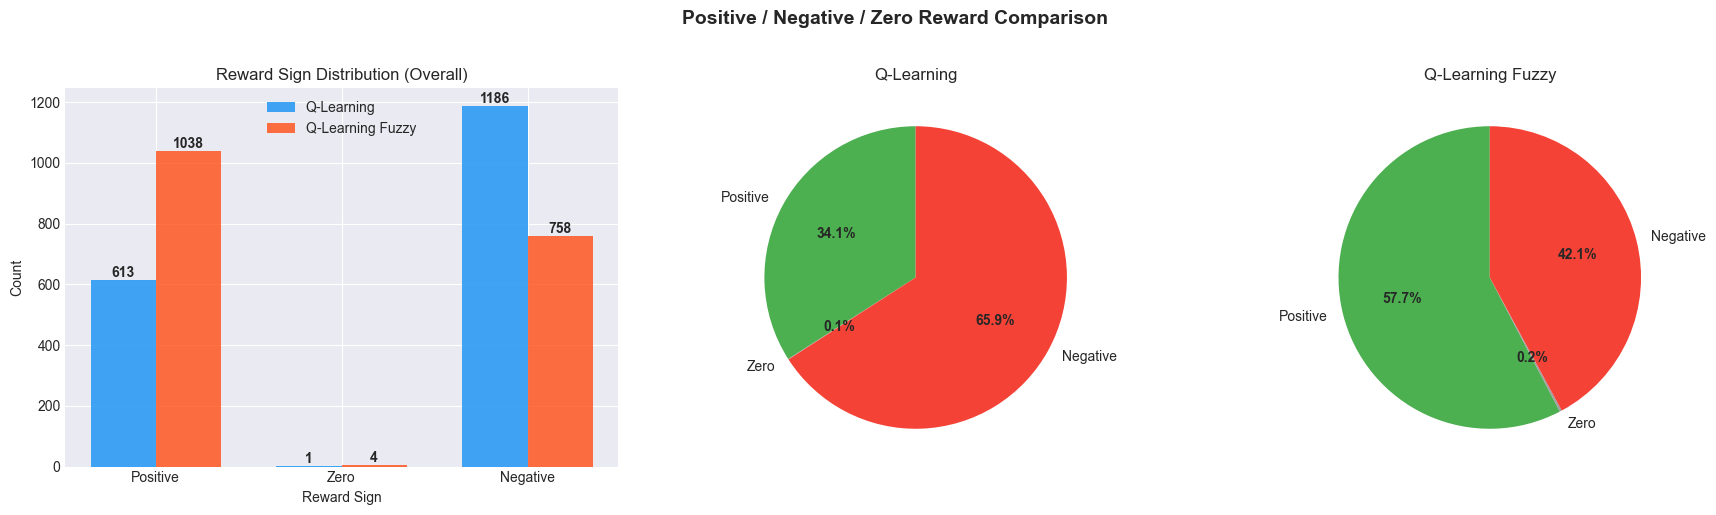

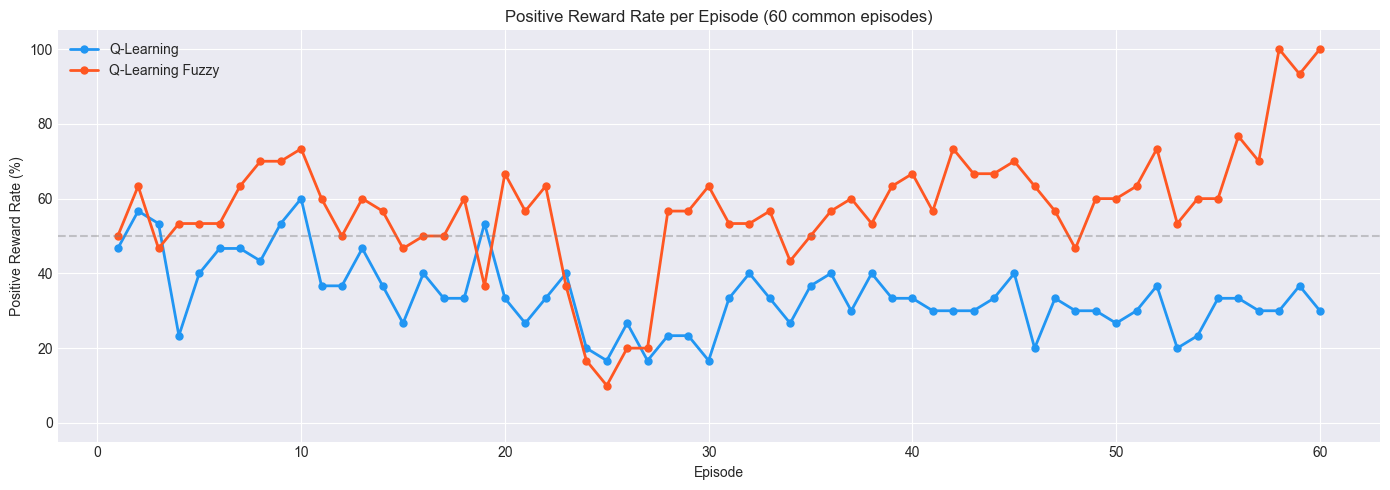

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 1) Overall bar chart comparison ---
ax = axes[0]
sign_labels = ['Positive', 'Zero', 'Negative']
sign_colors = ['#4CAF50', '#9E9E9E', '#F44336']

ql_counts = [(df_ql['reward'] > 0).sum(), (df_ql['reward'] == 0).sum(), (df_ql['reward'] < 0).sum()]
qf_counts = [(df_qf['reward'] > 0).sum(), (df_qf['reward'] == 0).sum(), (df_qf['reward'] < 0).sum()]

x = np.arange(len(sign_labels))
width = 0.35
bars1 = ax.bar(x - width/2, ql_counts, width, label='Q-Learning', color='#2196F3', alpha=0.85)
bars2 = ax.bar(x + width/2, qf_counts, width, label='Q-Learning Fuzzy', color='#FF5722', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 2,
            f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Reward Sign')
ax.set_ylabel('Count')
ax.set_title('Reward Sign Distribution (Overall)')
ax.set_xticks(x)
ax.set_xticklabels(sign_labels)
ax.legend()

# --- 2) Pie chart Q-Learning ---
ax = axes[1]
ql_total = len(df_ql)
ql_pcts = [c / ql_total * 100 for c in ql_counts]
wedges, texts, autotexts = ax.pie(
    ql_counts, labels=sign_labels, colors=sign_colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 10})
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Q-Learning')

# --- 3) Pie chart Q-Learning Fuzzy ---
ax = axes[2]
wedges, texts, autotexts = ax.pie(
    qf_counts, labels=sign_labels, colors=sign_colors, autopct='%1.1f%%',
    startangle=90, textprops={'fontsize': 10})
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Q-Learning Fuzzy')

fig.suptitle('Positive / Negative / Zero Reward Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- Per-episode positive reward rate (line chart) ---
fig, ax = plt.subplots(figsize=(14, 5))

ql_pos_rate = df_ql_cmp.groupby('episode')['reward'].apply(lambda r: (r > 0).mean() * 100)
qf_pos_rate = df_qf_cmp.groupby('episode')['reward'].apply(lambda r: (r > 0).mean() * 100)

ax.plot(ql_pos_rate.index, ql_pos_rate.values, marker='o', markersize=5,
        linewidth=2, label='Q-Learning', color='#2196F3')
ax.plot(qf_pos_rate.index, qf_pos_rate.values, marker='o', markersize=5,
        linewidth=2, label='Q-Learning Fuzzy', color='#FF5722')

ax.set_xlabel('Episode')
ax.set_ylabel('Positive Reward Rate (%)')
ax.set_title(f'Positive Reward Rate per Episode ({len(common_episodes)} common episodes)')
ax.legend()
ax.set_ylim(-5, 105)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.4, label='50% line')

plt.tight_layout()
plt.show()

## 5. Metrics Over Training

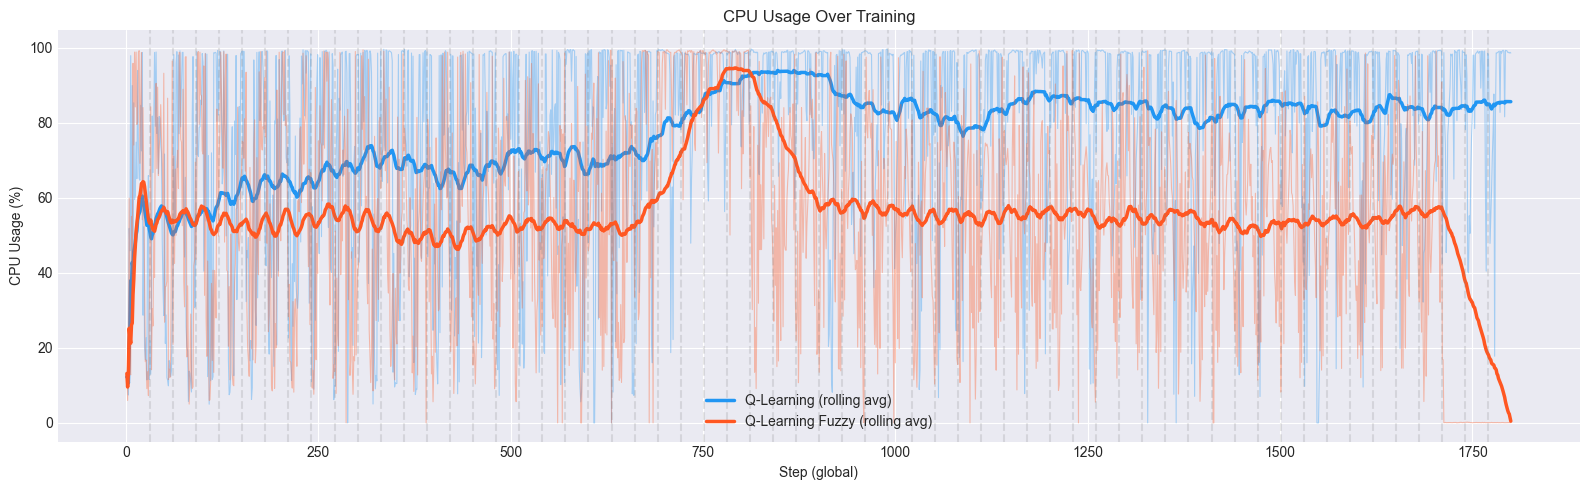

In [11]:
# --- CPU Usage ---
fig, ax = plt.subplots(figsize=(16, 5))

for label, df, color in [('Q-Learning', df_ql, '#2196F3'), ('Q-Learning Fuzzy', df_qf, '#FF5722')]:
    steps = range(1, len(df) + 1)
    ax.plot(steps, df['cpu_usage'], linewidth=0.8, color=color, alpha=0.35)
    window = max(1, len(df) // 20)
    ax.plot(steps, df['cpu_usage'].rolling(window, min_periods=1).mean(),
            linewidth=2.5, color=color, label=f'{label} (rolling avg)')

for ep in df_ql['episode'].unique()[1:]:
    idx = df_ql[df_ql['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.2)

ax.set_xlabel('Step (global)')
ax.set_ylabel('CPU Usage (%)')
ax.set_title('CPU Usage Over Training')
ax.legend()
plt.tight_layout()
plt.show()

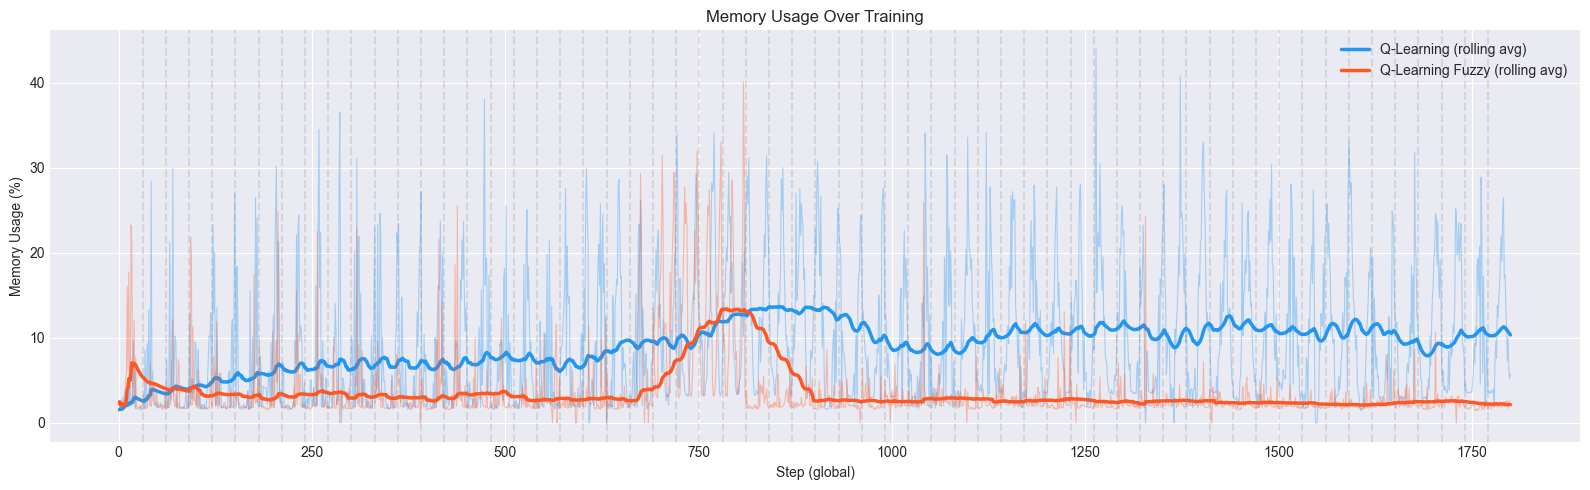

In [12]:
# --- Memory Usage ---
fig, ax = plt.subplots(figsize=(16, 5))

for label, df, color in [('Q-Learning', df_ql, '#2196F3'), ('Q-Learning Fuzzy', df_qf, '#FF5722')]:
    steps = range(1, len(df) + 1)
    ax.plot(steps, df['memory_usage'], linewidth=0.8, color=color, alpha=0.35)
    window = max(1, len(df) // 20)
    ax.plot(steps, df['memory_usage'].rolling(window, min_periods=1).mean(),
            linewidth=2.5, color=color, label=f'{label} (rolling avg)')

for ep in df_ql['episode'].unique()[1:]:
    idx = df_ql[df_ql['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.2)

ax.set_xlabel('Step (global)')
ax.set_ylabel('Memory Usage (%)')
ax.set_title('Memory Usage Over Training')
ax.legend()
plt.tight_layout()
plt.show()

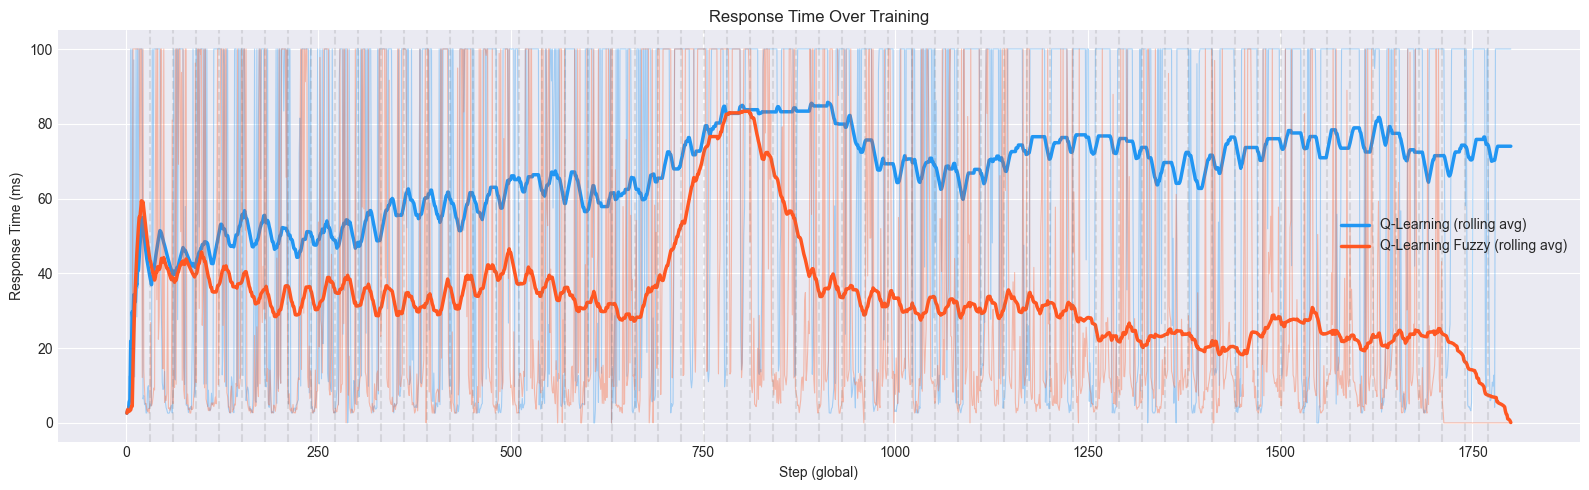

In [13]:
# --- Response Time ---
fig, ax = plt.subplots(figsize=(16, 5))

for label, df, color in [('Q-Learning', df_ql, '#2196F3'), ('Q-Learning Fuzzy', df_qf, '#FF5722')]:
    steps = range(1, len(df) + 1)
    ax.plot(steps, df['response_time'], linewidth=0.8, color=color, alpha=0.35)
    window = max(1, len(df) // 20)
    ax.plot(steps, df['response_time'].rolling(window, min_periods=1).mean(),
            linewidth=2.5, color=color, label=f'{label} (rolling avg)')

for ep in df_ql['episode'].unique()[1:]:
    idx = df_ql[df_ql['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.2)

ax.set_xlabel('Step (global)')
ax.set_ylabel('Response Time (ms)')
ax.set_title('Response Time Over Training')
ax.legend()
plt.tight_layout()
plt.show()

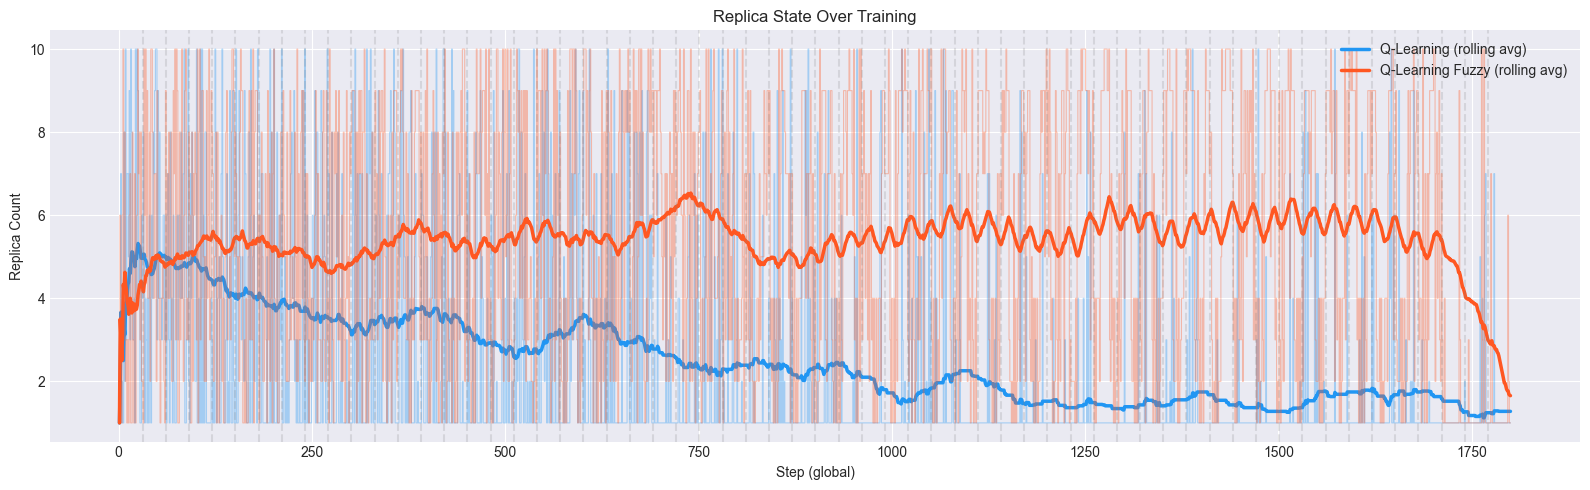

In [14]:
# --- Replica State ---
fig, ax = plt.subplots(figsize=(16, 5))

for label, df, color in [('Q-Learning', df_ql, '#2196F3'), ('Q-Learning Fuzzy', df_qf, '#FF5722')]:
    steps = range(1, len(df) + 1)
    ax.step(steps, df['replica_state'], linewidth=0.8, color=color, alpha=0.35, where='mid')
    window = max(1, len(df) // 20)
    ax.plot(steps, df['replica_state'].rolling(window, min_periods=1).mean(),
            linewidth=2.5, color=color, label=f'{label} (rolling avg)')

for ep in df_ql['episode'].unique()[1:]:
    idx = df_ql[df_ql['episode'] == ep].index[0]
    ax.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.2)

ax.set_xlabel('Step (global)')
ax.set_ylabel('Replica Count')
ax.set_title('Replica State Over Training')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Epsilon Decay & Replica Actions

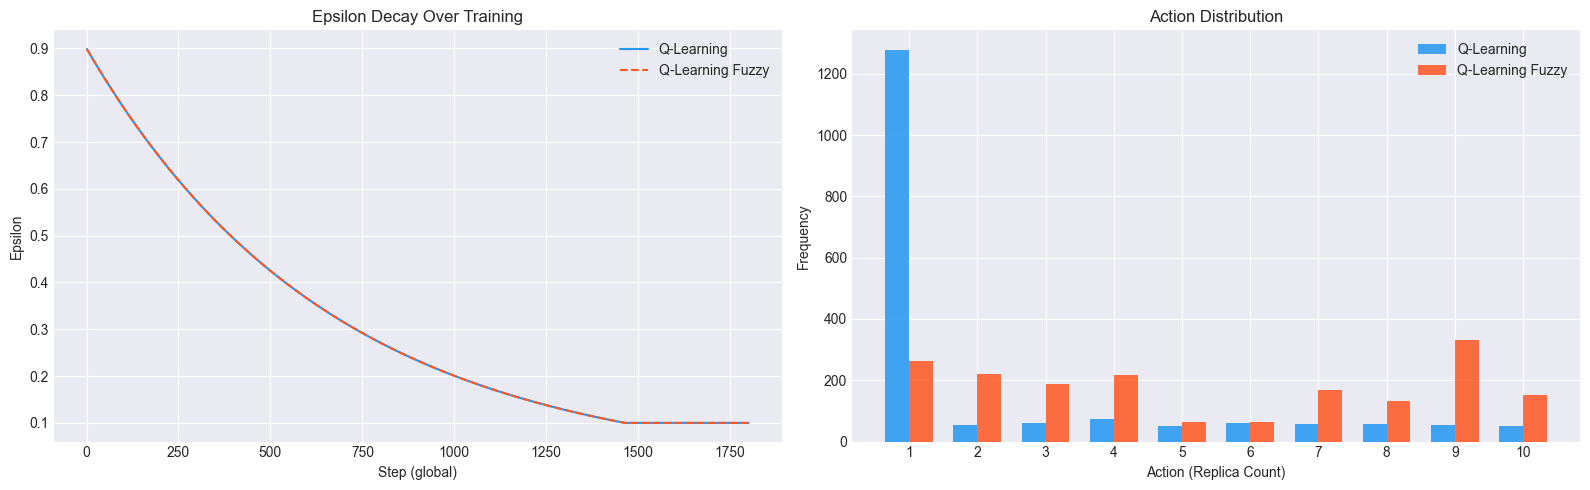

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Epsilon decay ---
ax = axes[0]
ax.plot(range(1, len(df_ql)+1), df_ql['epsilon'], linewidth=1.5, label='Q-Learning', color='#2196F3')
ax.plot(range(1, len(df_qf)+1), df_qf['epsilon'], linewidth=1.5, linestyle='--', label='Q-Learning Fuzzy', color='#FF5722')
ax.set_xlabel('Step (global)')
ax.set_ylabel('Epsilon')
ax.set_title('Epsilon Decay Over Training')
ax.legend()

# --- Right: Action (replica count) distribution ---
ax = axes[1]
ql_actions = df_ql['action'].value_counts().sort_index()
qf_actions = df_qf['action'].value_counts().sort_index()

all_actions = sorted(set(ql_actions.index) | set(qf_actions.index))
x = np.arange(len(all_actions))
width = 0.35

ql_vals = [ql_actions.get(a, 0) for a in all_actions]
qf_vals = [qf_actions.get(a, 0) for a in all_actions]

ax.bar(x - width/2, ql_vals, width, label='Q-Learning', color='#2196F3', alpha=0.85)
ax.bar(x + width/2, qf_vals, width, label='Q-Learning Fuzzy', color='#FF5722', alpha=0.85)
ax.set_xlabel('Action (Replica Count)')
ax.set_ylabel('Frequency')
ax.set_title('Action Distribution')
ax.set_xticks(x)
ax.set_xticklabels(all_actions)
ax.legend()

plt.tight_layout()
plt.show()

## 7. Reward vs Response Time & Replicas

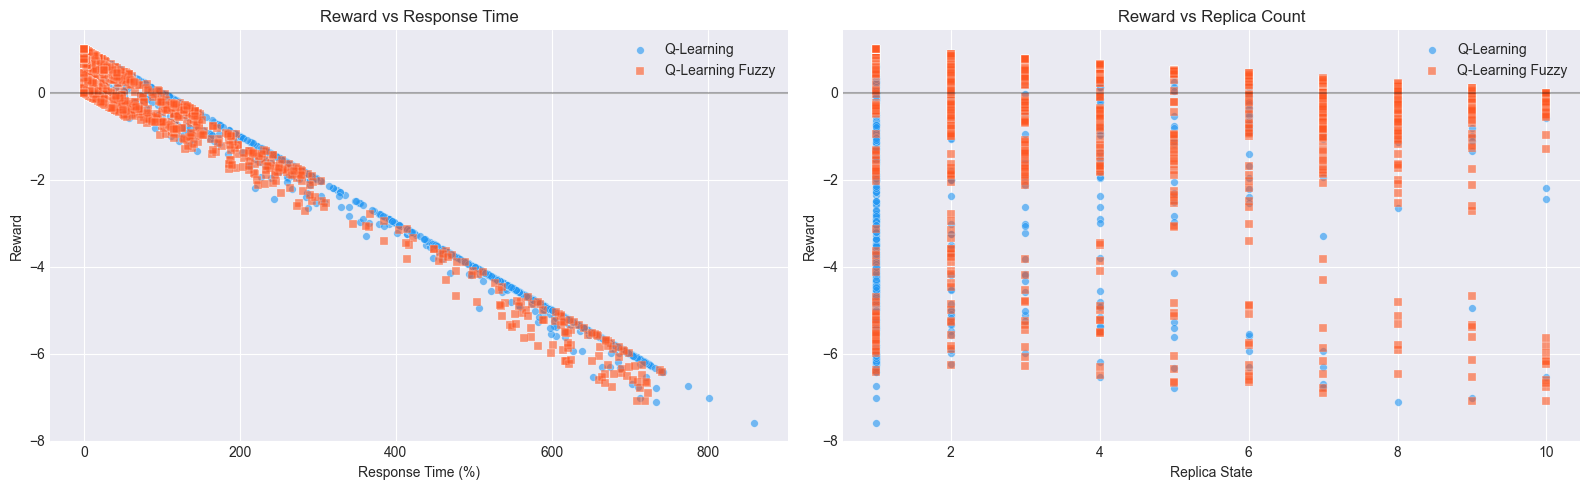

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: Reward vs Response Time ---
ax = axes[0]
ax.scatter(df_ql['response_time_percentage'], df_ql['reward'], alpha=0.6, s=30, label='Q-Learning', color='#2196F3', edgecolors='white', linewidth=0.3)
ax.scatter(df_qf['response_time_percentage'], df_qf['reward'], alpha=0.6, s=30, label='Q-Learning Fuzzy', color='#FF5722', marker='s', edgecolors='white', linewidth=0.3)
ax.set_xlabel('Response Time (%)')
ax.set_ylabel('Reward')
ax.set_title('Reward vs Response Time')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# --- Right: Reward vs Replica State ---
ax = axes[1]
ax.scatter(df_ql['replica_state'], df_ql['reward'], alpha=0.6, s=30, label='Q-Learning', color='#2196F3', edgecolors='white', linewidth=0.3)
ax.scatter(df_qf['replica_state'], df_qf['reward'], alpha=0.6, s=30, label='Q-Learning Fuzzy', color='#FF5722', marker='s', edgecolors='white', linewidth=0.3)
ax.set_xlabel('Replica State')
ax.set_ylabel('Reward')
ax.set_title('Reward vs Replica Count')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()